In [1]:
from transformer_lens import HookedTransformer
import torch
from ipe.nodes import Node, ATTN_Node, MLP_Node, EMBED_Node, FINAL_Node
from ipe.metrics import target_logit_percentage
from ipe.paths import evaluate_path, get_path
from ipe.miscellanea import batch_iterable
from tqdm import tqdm
from typing import Callable
import gc
import heapq
import time


def PathAttributionPatching_tests(
    model: HookedTransformer,
    metric: Callable,
    root: Node,
    min_contribution: float = 0.5,
    include_negative: bool = True,
    return_all: bool = False,
    confirm_relevance: bool = False
) -> tuple[list[tuple[torch.Tensor, list[Node]]], list[tuple[tuple[torch.Tensor, torch.Tensor], list[Node]]]]:
    """
    Performs a Breadth-First Search (BFS) starting from a node backwards to identify
    the most significant paths reaching it from an EMBED_Node.

    Args:
        model (HookedTransformer): 
            The transformer model used for evaluation.
        msg_cache (ActivationCache): 
            The activation cache containing intermediate activations.
        metric (Callable):
            A function to evaluate the contribution or importance of the path.
                It must accept a single parameter corresponding to the corrupted residual stream just before the final layer norm.
        root (Node): 
            The initial node to begin the backward search from (e.g., FINAL_Node(layer=model.cfg.n_layers - 1, position=target_pos)).
        ground_truth_tokens (list of int): 
            The reference tokens used for evaluating path contributions.
        min_contribution (float, default=0.5): 
            The minimum absolute contribution score required for a path to be considered valid.
        include_negative (bool, default=False): 
            If True, include paths with negative contributions. The min_contribution is therefore interpreted as a threshold on the magnitude of the contribution.
        return_all (bool, default=False): 
            If True, return all evaluated paths regardless of their contribution score. The search will still be guided by min_contribution threshold.
        confirm_relevance (bool, default=False):
            If True, after identifying a potentially relevant component based on the linear approximation, it will also evaluate the contribution of the full path including to confirm its relevance.
    Returns:
        A list of tuples containing the contribution score and the corresponding path, sorted by contribution in descending order.

        A list of tuples containing all the attribution scores and exact scores of complete and incomplete paths evaluated during the search.
    """
    frontier = [root]
    completed_paths = []
    all_evaluated_paths = []
    while frontier:
        cur_depth_frontier = []
        # Expand all paths in the frontier looking for meaningful continuations
        for node in tqdm(frontier):

            grad = node.calculate_gradient(use_precomputed=True)
            with torch.no_grad():
                childrens = []

                candidate_components = node.get_expansion_candidates(model.cfg, include_head=True) 

                # Get the meaningful candidates for expansion
                for candidate_batch in batch_iterable(candidate_components, 128):
                    candidate_paths_contributions = []
                    msgs_list = []
                    for candidate in candidate_batch:
                        backup_pos = candidate.position
                        candidate.position = None
                        msg = candidate.forward(message=None)
                        msgs_list.append(msg)
                        candidate.position = backup_pos
                        candidate_paths_contributions.append(evaluate_path(get_path(candidate), metric))
                    candidate_contributions = torch.stack(msgs_list, dim=0)
                    

                    approx_contributions = torch.einsum('xbsd,bsd->x', candidate_contributions, grad)
                    for i, candidate in enumerate(candidate_batch):
                        approx_contribution = approx_contributions[i]
                        contribution = candidate_paths_contributions[i]
                        all_evaluated_paths.append(((approx_contribution, contribution), get_path(candidate)))
                        # EMBED is the base case
                        if candidate.__class__.__name__ == 'EMBED_Node':
                            candidate_path = get_path(candidate)
                            if return_all:
                                completed_paths.append((contribution, candidate_path))
                            elif include_negative:
                                if abs(contribution.item()) >= min_contribution:
                                    if confirm_relevance:
                                        if abs(contribution) >= min_contribution:
                                            completed_paths.append((contribution, candidate_path))
                                    else:
                                        completed_paths.append((contribution, candidate_path))
                            elif contribution >= min_contribution:
                                if confirm_relevance:
                                    if contribution >= min_contribution:
                                        completed_paths.append((contribution, candidate_path))
                                else:
                                    completed_paths.append((contribution, candidate_path))
                                
                        
                        # MLP requires to check the contribution of the whole component and of the individual layers
                        elif candidate.__class__.__name__ == 'MLP_Node' or candidate.__class__.__name__ == 'ATTN_Node':
                            if include_negative:
                                if abs(approx_contribution.item()) >= min_contribution:
                                    if confirm_relevance:
                                        contribution = evaluate_path(get_path(candidate), metric)
                                        if abs(contribution) >= min_contribution:
                                            childrens.append(candidate)
                                    else:
                                        childrens.append(candidate)
                            elif approx_contribution >= min_contribution:
                                if confirm_relevance:
                                    contribution = evaluate_path(get_path(candidate), metric)
                                    if contribution >= min_contribution:
                                        childrens.append(candidate)
                                else:
                                    childrens.append(candidate)
                cur_depth_frontier.extend(childrens)
                node.children = childrens
                if len(childrens) == 0:
                    node.gradient = None # Free the gradient of the node if it has no children to save memory
        
        for node in frontier: # Free the gradient of the parent nodes to save memory
            if node.parent is not None and node.parent.gradient is not None:
                node.parent.gradient = None
        gc.collect() # Reclaim memory
        torch.cuda.empty_cache()

        frontier = cur_depth_frontier

    return sorted(completed_paths, key=lambda x: x[0], reverse=True), all_evaluated_paths


In [7]:
from functools import partial

model = HookedTransformer.from_pretrained("gpt2-small")
prompt = "The capital of France is"
target = " Paris"
logits, cache = model.run_with_cache(prompt + target)
#(clean_final_resid: Tensor, corrupted_resid: Tensor, model: HookedTransformer, target_tokens: list[int]) -> Tensor
metric = partial(
    target_logit_percentage,
    clean_final_resid=cache["blocks.11.hook_resid_post"],
    model=model,
    target_tokens=model.to_tokens(target, prepend_bos=False)[0].tolist()
)
min_contribution = 2.5
root = FINAL_Node(
    model=model,
    layer=model.cfg.n_layers - 1,
    position=cache['hook_embed'].shape[1] - 1,
    msg_cache=dict(cache),
    metric=metric
)

relevant_paths, all_evaluated_paths = PathAttributionPatching_tests(
    model=model,
    metric=metric,
    root=root,
    min_contribution=2.5
)

Loaded pretrained model gpt2-small into HookedTransformer


100%|██████████| 35/35 [00:01<00:00, 30.59it/s]


Total paths evaluated: 73047
Number of misclassified paths (approx < 2.5 but exact >= 2.5): 63


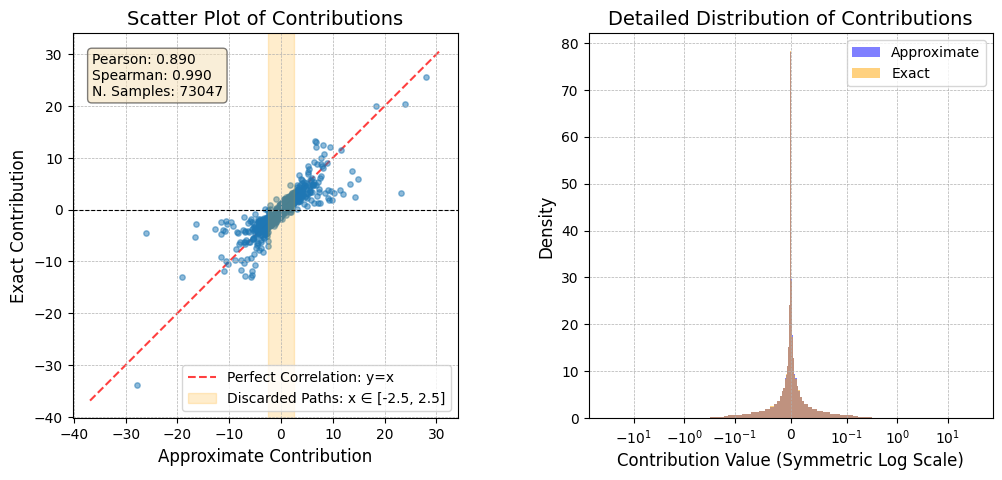

In [13]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

import matplotlib.pyplot as plt

# Extract approximate and exact scores from the results
approx_scores = np.array([x[0][0].item() for x in all_evaluated_paths])
exact_scores = np.array([x[0][1].item() for x in all_evaluated_paths])

# Calculate the number of paths misclassified by the approximation
misclassified_mask = (np.abs(approx_scores) < min_contribution) & (np.abs(exact_scores) >= min_contribution)
misclassified_count = np.sum(misclassified_mask)
print(f"Total paths evaluated: {len(approx_scores)}")
print(f"Number of misclassified paths (approx < {min_contribution} but exact >= {min_contribution}): {misclassified_count}")


# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.3)

# 1. Scatter Plot
ax1.scatter(approx_scores, exact_scores, alpha=0.5, s=15)
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)

# Perfect correlation line
lims = [
    min(ax1.get_xlim()[0], ax1.get_ylim()[0]),
    max(ax1.get_xlim()[1], ax1.get_ylim()[1]),
]
ax1.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Correlation: y=x')

# Discarded paths region
ax1.axvspan(-min_contribution, min_contribution, color='orange', alpha=0.2, label=f'Discarded Paths: x ∈ [{-min_contribution}, {min_contribution}]')

# Correlations and sample size text box
pearson_corr, _ = pearsonr(approx_scores, exact_scores)
spearman_corr, _ = spearmanr(approx_scores, exact_scores)
textstr = '\n'.join((
    f'Pearson: {pearson_corr:.3f}',
    f'Spearman: {spearman_corr:.3f}',
    f'N. Samples: {len(approx_scores)}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax1.set_xlabel('Approximate Contribution', fontsize=12)
ax1.set_ylabel('Exact Contribution', fontsize=12)
ax1.set_title('Scatter Plot of Contributions', fontsize=14)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend()
ax1.set_aspect('equal', 'box')


# 2. Distribution Plot
bins = np.geomspace(0.001, max(np.abs(approx_scores).max(), np.abs(exact_scores).max()), 50)
bins = sorted(list(-bins) + list(bins))

ax2.hist(approx_scores, bins=bins, alpha=0.5, label='Approximate', density=True, color='blue')
ax2.hist(exact_scores, bins=bins, alpha=0.5, label='Exact', density=True, color='orange')
ax2.set_xscale('symlog', linthresh=0.1)
ax2.set_xlabel('Contribution Value (Symmetric Log Scale)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Detailed Distribution of Contributions', fontsize=14)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.legend()

plt.show()